In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('./results', exist_ok=True)

with open('./brown_100.txt', 'r') as file_:
    corpus = file_.read()

def write_freqs(list_: list, filename: str) -> None:
    with open(f'./results/{filename}.txt', 'w') as file_:
        file_.write('\n'.join([' '.join(x[0]) + ' | ' + str(x[1]) for x in list_]))

## N-Gram Language Modeling
In the second assignment, you will implement an **n-gram language model** that processes input text to generate, analyze, and calculate the probabilities of sequences of `n` words (n-grams). This model will tokenize text, create n-grams, and compute their frequencies and probabilities, returning the most frequent n-grams in the text.

1. **Tokenization**: Convert the input text into a list of words (tokens).
2. **N-gram Generation**: Create sequences of `n` tokens from the text, treating each sentence independently with the inclusion of start (`<s>`) and end (`</s>`) markers.
3. **Frequency Counting**: Count how many times each n-gram appears in the text.
4. **Probability Calculation**: Compute the probabilities of each n-gram based on its frequency and add alpha smoothing to improve generalization of items.
5. **Most Frequent N-grams**: Return the most frequent n-grams along with their probabilities, helping to identify common patterns in the text.

In [12]:
from collections import Counter, defaultdict  # You may import more from collections if needed
import random

class NGramModel:
    def __init__(self, text, n, alpha=0.0):
        """
        Initialize the NGramModel with text and the value of n.
        """
        self.text = text
        self.n = n
        self.alpha = alpha  # Alpha value for additive smoothing
        self.ngrams = {}
        self.probabilities = {}
        self.vocab = set()
        # keep context counts around so we can compute conditional probs for n > 1
        self.context_counts = {}

    def tokenize(self) -> None:
        """
        Tokenize the text into words. 
        The brown_100.txt corpus already marks sentences with <s> and </s>,
        so I split on whitespace and keep those tags as tokens.
        I also lowercase everything except the sentence markers so that
        "The" and "the" count as the same word.
        """
        tokens = []
        for tok in self.text.split():
            if tok == '<s>' or tok == '</s>':
                tokens.append(tok)
            else:
                tokens.append(tok.lower())

        # build the vocabulary from actual word tokens (skip sentence markers)
        self.vocab = set(t for t in tokens if t not in ('<s>', '</s>'))
        return tokens

    def generate_ngrams(self, tokens: list) -> dict:
        """
        Generate n-grams from the list of tokens.
        Each sentence is treated independently: I first split the token list
        into sentences using <s> ... </s>, and then slide a window of size n
        over each sentence.
        """
        # split tokens into sentences based on <s> ... </s>
        sentences = []
        current = []
        inside = False
        for tok in tokens:
            if tok == '<s>':
                current = ['<s>']
                inside = True
            elif tok == '</s>':
                if inside:
                    current.append('</s>')
                    sentences.append(current)
                    current = []
                    inside = False
            else:
                if inside:
                    current.append(tok)

        # now build n-grams per sentence
        ngram_list = []
        for sent in sentences:
            if len(sent) < self.n:
                continue
            for i in range(len(sent) - self.n + 1):
                ngram_list.append(tuple(sent[i:i + self.n]))

        # store as a dict {ngram: count} using Counter later,
        # but for now keep the raw list too so count_frequencies can use it
        self._ngram_list = ngram_list
        self.ngrams = dict(Counter(ngram_list))
        return self.ngrams

    def count_frequencies(self) -> None:
        """
        Count the frequencies of each n-gram.
        Also count how often each (n-1)-gram context appears — we need this
        for the conditional probability P(w_n | w_1 ... w_{n-1}).
        """
        self.ngrams = dict(Counter(self._ngram_list))

        # count contexts (the first n-1 words of each n-gram)
        # for unigrams the "context" is empty, and we just use the total token count
        if self.n == 1:
            self.context_counts = {(): sum(self.ngrams.values())}
        else:
            ctx_counter = Counter()
            for ngram, cnt in self.ngrams.items():
                ctx_counter[ngram[:-1]] += cnt
            self.context_counts = dict(ctx_counter)

    def calculate_probabilities(self) -> None:
        """
        Calculate probabilities of each n-gram.
        With alpha=0 this is just MLE: count(ngram) / count(context).
        With alpha > 0 we apply additive (Laplace-style) smoothing:
            P(w_n | context) = (count(ngram) + alpha) / (count(context) + alpha * V)
        where V is the vocabulary size.
        """
        V = len(self.vocab)
        self.probabilities = {}

        for ngram, count in self.ngrams.items():
            context = ngram[:-1]  # empty tuple for unigrams
            ctx_count = self.context_counts.get(context, 0)

            if self.alpha > 0:
                prob = (count + self.alpha) / (ctx_count + self.alpha * V)
            else:
                prob = count / ctx_count if ctx_count > 0 else 0.0

            self.probabilities[ngram] = prob

    def most_frequent_ngrams(self, top_n: int = 10) -> list:
        """
        Return the most frequent n-grams together with their probabilities.
        Output format: [(ngram_tuple, probability), ...]
        This matches what write_freqs() expects.
        """
        # sort by raw frequency (descending), then take the top_n
        sorted_by_count = sorted(self.ngrams.items(), key=lambda x: x[1], reverse=True)
        top = sorted_by_count[:top_n]

        sorted_grams = [(ngram, self.probabilities[ngram]) for ngram, _ in top]
        return sorted_grams


# Testing the model with an example
text = "This is a simple example to demonstrate how n-grams work in this assignment. "  # Faster than running the full corpus
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(text, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

# Print the most frequent n-grams
print(model.most_frequent_ngrams(10))

[]


### Unigrams

In this section, we apply the `NGramModel` to our corpus. The model can be configured to generate unigrams, bigrams, or trigrams by adjusting the value of `n`. After tokenizing the text and generating the n-grams, the model counts the occurrences of each n-gram and calculates their probabilities. The most frequent n-grams are then written to an output file.

By adjusting the n-gram size, we can analyze different levels of word dependencies in the text, providing insights into common word sequences and patterns.  

The code below will generate unigrams when the NGramModel is implemented correctly

In [13]:
n = 1  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'unigrams')

### Bigrams
Bigrams allow us to explore word pairs and their relationships, providing insight into common word combinations and phrase structures within the corpus.  
The code below will generate bigrams when the NGramModel is implemented correctly.

In [14]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams')

### Trigrams
Trigrams capture three-word sequences, providing a deeper understanding of longer word dependencies and commonly occurring phrases within the text.  
The code below will generate trigrams when the NGramModel is implemented correctly

In [15]:
n = 3  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'trigrams')

### Smoothing
Below, we generate **bigrams** with **smoothing** applied by setting `n = 2` and including a smoothing parameter `alpha = 1.0`. Smoothing is useful in language models to handle unseen n-grams by assigning a small probability to them. The model tokenizes the text, generates bigrams, counts their frequencies, and calculates smoothed probabilities. The most frequent bigrams are then written to an output file.





In [16]:
n = 2  # You can change this to 1, 2, or 3 for uni, bi, or trigrams
model = NGramModel(corpus, n, alpha=1.0)

tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()

write_freqs(model.most_frequent_ngrams(10), 'bigrams_smoothed')

In [17]:
# Experimenting with different alpha values to see how smoothing affects the model
print("Top bigram probabilities for different alpha values:\n")

for a in [0.0, 0.01, 0.1, 1.0, 5.0]:
    m = NGramModel(corpus, 2, alpha=a)
    toks = m.tokenize()
    m.generate_ngrams(toks)
    m.count_frequencies()
    m.calculate_probabilities()
    top = m.most_frequent_ngrams(5)
    print(f"alpha = {a}")
    for ngram, prob in top:
        print(f"  {' '.join(ngram):20s}  p = {prob:.6f}")
    print()

Top bigram probabilities for different alpha values:

alpha = 0.0
  . </s>                p = 1.000000
  <s> the               p = 0.270000
  in the                p = 0.400000
  , the                 p = 0.181818
  '' .                  p = 0.441176

alpha = 0.01
  . </s>                p = 0.916589
  <s> the               p = 0.249838
  in the                p = 0.332779
  , the                 p = 0.166580
  '' .                  p = 0.356447

alpha = 0.1
  . </s>                p = 0.523810
  <s> the               p = 0.149641
  in the                p = 0.132948
  , the                 p = 0.095210
  '' .                  p = 0.131190

alpha = 1.0
  . </s>                p = 0.100000
  <s> the               p = 0.030735
  in the                p = 0.019976
  , the                 p = 0.018910
  '' .                  p = 0.018935

alpha = 5.0
  . </s>                p = 0.022683
  <s> the               p = 0.007702
  in the                p = 0.005128
  , the                 p = 0.

### Generating Text
In this example, we generate text using the **bigrams** model by providing a starting **prompt** (e.g., "the jury"). The `generate_text` function creates a sequence of words based on the trained bigram model, starting from the provided prompt and continuing based on the probabilities of the next words.

After tokenizing the corpus, generating bigrams, and calculating their frequencies and probabilities, the model uses these learned probabilities to generate text. The generated output is then written to a file.

Text generation with n-grams helps illustrate how language models can predict word sequences, allowing us to create new sentences that follow similar patterns found in the original text.

In [18]:
def generate_text(model: NGramModel, n: int, prompt: str, max_length: int = 30) -> str:
    """
    Generate text from a trained n-gram model, starting from `prompt`.
    At each step I look at the last (n-1) tokens as context, find all n-grams
    in the model that start with that context, and sample the next word using
    their probabilities (weighted random choice). Stops at </s> or max_length.
    """
    generated_tokens = prompt.lower().split()

    # build a lookup: context -> list of (next_word, probability)
    context_to_next = defaultdict(list)
    for ngram, prob in model.probabilities.items():
        context = ngram[:-1]
        next_word = ngram[-1]
        context_to_next[context].append((next_word, prob))

    for _ in range(max_length):
        # take the last n-1 tokens as context (empty tuple if unigram)
        context = tuple(generated_tokens[-(n - 1):]) if n > 1 else ()

        candidates = context_to_next.get(context, [])
        if not candidates:
            break

        # weighted random sample based on probabilities
        words, probs = zip(*candidates)
        total = sum(probs)
        probs_norm = [p / total for p in probs]
        next_word = random.choices(words, weights=probs_norm, k=1)[0]

        if next_word == '</s>':
            break
        generated_tokens.append(next_word)

    return ' '.join(generated_tokens)


tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)
model.count_frequencies()
model.calculate_probabilities()
generated_text = generate_text(model, 2, 'the jury')
with open(f'./results/generated_bigrams.txt', 'w') as file_:
    file_.write(generated_text)

## Word Vectors
Note: This part of the notebook was originally written for a corpus based on movie reviews from IMDb, based on a Stanford course (https://web.stanford.edu/class/cs224n/). Part of your task is to adapt this portion of the notebook to the corpora used in the previous parts of the assignment: namely, the Brown Corpus and the Indian Language Corpus. You will need to access these corpora from NLTK and perform all functions for both corpora. Note down any updates in the code in your comments.

### Count based W2V
In this section, we use the previously trained **n-gram model** to calculate a **co-occurrence matrix**. A co-occurrence matrix shows how often words appear together within a specific context (in this case, bigrams), providing insights into word relationships in the corpus.

Steps:
1. **Tokenization and N-gram Generation**: We first tokenize the text and generate bigrams using the `NGramModel`.
2. **Vocabulary and Indexing**: The vocabulary is created from the unique tokens, and a word-to-index mapping is established.
3. **Co-occurrence Matrix**: Using the generated n-grams, we compute the co-occurrence matrix, where each entry represents how often two words occur together within the bigrams.

The co-occurrence matrix provides a numerical representation of word relationships, which is useful for tasks like word embeddings, semantic analysis, and understanding word associations.

In [19]:
# Since we already have a working ngram model, for the next part we can use the ngrams to calculate the co-occurrences.
model = NGramModel(corpus, 2)
tokens = model.tokenize()
ngrams = model.generate_ngrams(tokens)

def create_co_matrix(ngrams: list, vocab_size: int, word_to_index: dict) -> np.ndarray:
    """
    Build a symmetric co-occurrence matrix from the list of bigrams.
    ngrams is expected to be a dict {bigram_tuple: count} from the NGramModel,
    or a list of bigram tuples. Either way we iterate and accumulate counts.
    The matrix is symmetric because co-occurrence is order-insensitive here.
    """
    co_matrix = np.zeros((vocab_size, vocab_size), dtype=np.int32)

    # support both dict (ngram -> count) and list of bigrams
    if isinstance(ngrams, dict):
        iterable = ngrams.items()
    else:
        iterable = [(ng, 1) for ng in ngrams]

    for bigram, count in iterable:
        w1, w2 = bigram
        if w1 not in word_to_index or w2 not in word_to_index:
            continue
        i, j = word_to_index[w1], word_to_index[w2]
        co_matrix[i][j] += count
        co_matrix[j][i] += count  # symmetric
    return co_matrix


vocab = list(set(tokens))
vocab_size = len(vocab)

# Create a word-to-index mapping
word_to_index = {word: idx for idx, word in enumerate(vocab)}

# Generate the co-occurrence matrix
co_matrix = create_co_matrix(ngrams, vocab_size, word_to_index)

# sanity check: print the shape and a few statistics
print(f"Co-occurrence matrix shape: {co_matrix.shape}")
print(f"Total co-occurrences: {co_matrix.sum()}")
print(f"Non-zero entries: {np.count_nonzero(co_matrix)}")

Co-occurrence matrix shape: (813, 813)
Total co-occurrences: 4736
Non-zero entries: 3724


With the code below you can verify if the co-occurence works

In [20]:
def check_co_occurrence(word1, word2, co_matrix, word_to_index):
    """
    Print the co-occurrence count for a specific word pair.
    """
    if word1 not in word_to_index or word2 not in word_to_index:
        print(f"One or both words '{word1}' and '{word2}' are not in the vocabulary.")
        return

    index1 = word_to_index[word1]
    index2 = word_to_index[word2]

    co_count = co_matrix[index1][index2]
    print(f"Co-occurrence count for '{word1}' and '{word2}': {co_count}")

# Pairs chosen based on the content of brown_100.txt (news/political/legal text):
# 'the' + 'jury' appears often because the corpus is about a grand jury
# 'grand' + 'jury' is a fixed legal phrase
# 'fulton' + 'county' is a location repeatedly mentioned
# 'the' + 'cat' should be zero — there are no cats in a news corpus
check_co_occurrence('the', 'jury', co_matrix, word_to_index)
check_co_occurrence('grand', 'jury', co_matrix, word_to_index)
check_co_occurrence('fulton', 'county', co_matrix, word_to_index)
check_co_occurrence('the', 'cat', co_matrix, word_to_index)

Co-occurrence count for 'the' and 'jury': 13
Co-occurrence count for 'grand' and 'jury': 3
Co-occurrence count for 'fulton' and 'county': 6
One or both words 'the' and 'cat' are not in the vocabulary.


In this part, we reduce the dimensionality of the **co-occurrence matrix** using **Singular Value Decomposition (SVD)**. This technique helps in extracting the most important features from the matrix, making it easier to visualize and interpret the relationships between words.

Steps:
1. **Singular Value Decomposition (SVD)**: The co-occurrence matrix is decomposed into three matrices: \( M = U \cdot \Sigma \cdot V^T \).
2. **Dimensionality Reduction**: We retain only the top `k` components (default is 2) from the SVD, effectively reducing the dimensionality of the matrix.
3. **Reduced Matrix**: The reduced matrix retains the most important semantic information and can be used for tasks such as **word embedding visualization** or **semantic similarity analysis**.

Dimensionality reduction allows us to capture the essence of word relationships in fewer dimensions, making it more efficient to process and visualize the data.

In [21]:
def reduce_to_k_dim(M, k=2):
    """
    Reduce a matrix M of shape (n, d) to shape (n, k) using Truncated SVD.
    We use sklearn's TruncatedSVD which is designed for exactly this use case
    and handles sparse/large matrices better than numpy's full SVD.
    """
    from sklearn.decomposition import TruncatedSVD
    svd = TruncatedSVD(n_components=k, n_iter=10, random_state=42)
    M_reduced = svd.fit_transform(M)
    print(f"Reduced matrix shape: {M_reduced.shape}")
    return M_reduced

In this final part, we visualize the reduced word embeddings in **2D space**. After reducing the dimensionality of the co-occurrence matrix using SVD, we plot the embeddings for each word to observe their relationships in a low-dimensional space.

Steps:
1. **Plotting the Embeddings**: Each word from the vocabulary is plotted based on its 2D coordinates from the reduced matrix.
2. **Visualization**: The scatter plot allows us to see how words cluster together or relate to each other based on co-occurrences in the text. Words with similar contexts should appear closer to each other in the plot.
3. **Interpretation**: By looking at the 2D plot, we can analyze word similarities, relationships, and clusters formed by words that often occur together.

This visualization is a useful tool for understanding the structure of word embeddings and the relationships between words in the corpus.







Reduced matrix shape: (813, 2)


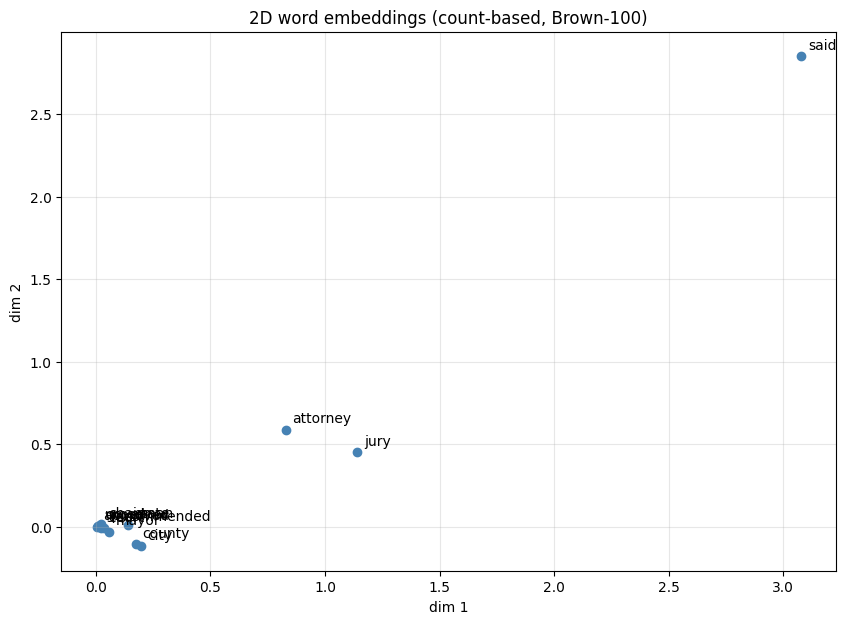

In [ ]:
def plot_embeddings(M_reduced, word_to_index, words):
    """
    Plot a selection of words in 2D space based on their reduced vectors.
    word_to_index maps each word to its row in M_reduced.
    Only plots words that are actually in the vocabulary.
    """
    plt.figure(figsize=(10, 7))
    for w in words:
        if w not in word_to_index:
            print(f"'{w}' not in vocabulary, skipping.")
            continue
        idx = word_to_index[w]
        x, y = M_reduced[idx, 0], M_reduced[idx, 1]
        plt.scatter(x, y, marker='o', color='steelblue')
        plt.annotate(w, (x, y), xytext=(5, 5), textcoords='offset points')
    plt.title("2D word embeddings (count-based, Brown-100)")
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.grid(True, alpha=0.3)
    plt.show()


# Actually reduce the co-occurrence matrix to 2D before plotting.
# This step was missing, the notebook defined reduce_to_k_dim but never called it on our co_matrix.

M_reduced = reduce_to_k_dim(co_matrix.astype(np.float64), k=2)

# Words adapted for the Brown-100 corpus. The original list was movie-review
# words ('movie', 'mysterious', etc.) which don't appear in news text.
# These are all words that actually appear in brown_100.txt and represent
# semantic categories we'd expect to cluster: legal/government, people,
# and time/action verbs.
words = ['jury', 'county', 'court', 'city', 'state',        # legal/governmental
         'mayor', 'governor', 'chairman', 'attorney',       # people/roles
         'said', 'recommended', 'approved', 'urged']        # reporting verbs

plot_embeddings(M_reduced, word_to_index, words)

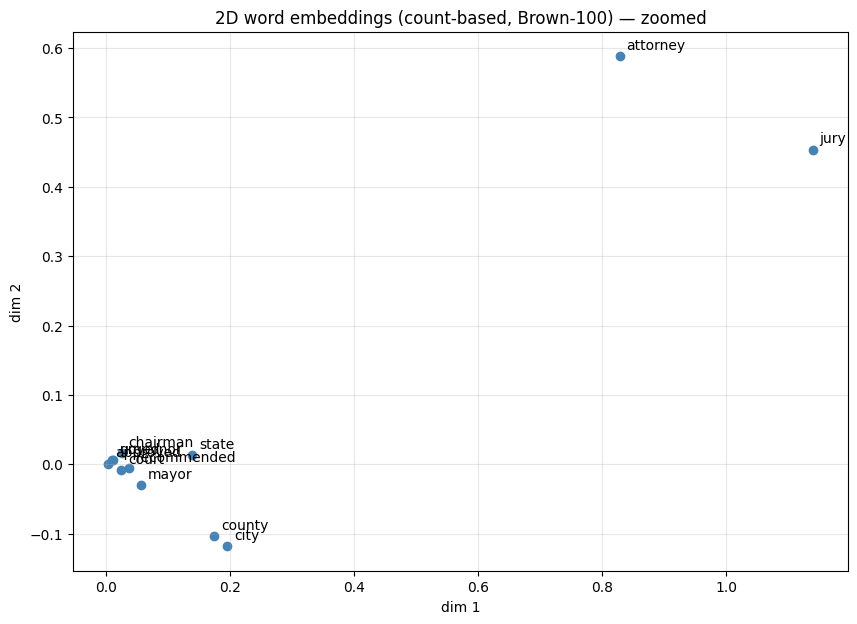

In [25]:
# Zoomed-in view of the cluster near the origin (excluding 'said' which dominates)
plt.figure(figsize=(10, 7))
for w in words:
    if w not in word_to_index or w == 'said':   # skip 'said', it's an outlier
        continue
    idx = word_to_index[w]
    x, y = M_reduced[idx, 0], M_reduced[idx, 1]
    plt.scatter(x, y, marker='o', color='steelblue')
    plt.annotate(w, (x, y), xytext=(5, 5), textcoords='offset points')
plt.title("2D word embeddings (count-based, Brown-100) — zoomed")
plt.xlabel("dim 1")
plt.ylabel("dim 2")
plt.grid(True, alpha=0.3)
plt.show()

## Prediction-Based Word Vectors
In this section, we load pre-trained word vectors using the **GloVe** embeddings from the [Stanford NLP paper on GloVe](https://nlp.stanford.edu/pubs/glove.pdf). The pre-trained embeddings provide rich semantic information about words based on large text corpora, allowing us to represent words as vectors that capture their meaning and relationships.

Steps:
1. **Load GloVe Word Vectors**: We use the GloVe embeddings from the `glove-wiki-gigaword-200` model, which has 200-dimensional vectors for each word.
2. **Vocabulary Matching**: We map the words from our corpus to the GloVe vocabulary and extract the corresponding vectors.
3. **Dimensionality Reduction**: After obtaining the word vectors, we reduce the dimensionality to visualize the embeddings in 2D space, allowing us to explore word relationships visually.

This is an excellent opportunity to explore how pre-trained embeddings like GloVe can be used to improve downstream NLP tasks by providing richer word representations.

In [27]:
# Do not edit
import gensim.downloader as api
import numpy as np
wv_from_bin = api.load("glove-wiki-gigaword-200")
print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))

wv_words = list(wv_from_bin.index_to_key)
unique_tokens = set(tokens)
word2ind = {}
M = []
idx = 0
print('rendering M based on wv')
for w in wv_words:
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass

print('rendering M based on unique_tokens')
for w in unique_tokens:
    if w in wv_words:
        continue
    try:
        M.append(wv_from_bin.get_vector(w))
        word2ind[w] = idx
        idx += 1
    except:
        pass
M = np.stack(M)
M_reduced = reduce_to_k_dim(M, k=2)

M_lengths = np.linalg.norm(M_reduced, axis=1)
M_reduced_normalized = M_reduced / M_lengths[:, np.newaxis]

[==================================================] 100.0% 252.1/252.1MB downloaded
Loaded vocab size 400000
rendering M based on wv
rendering M based on unique_tokens
Reduced matrix shape: (400000, 2)


### Compare plots
What stands out when comparing the two different ways of embedding using the given words?

(Use this to help answer the question in your assignment document).

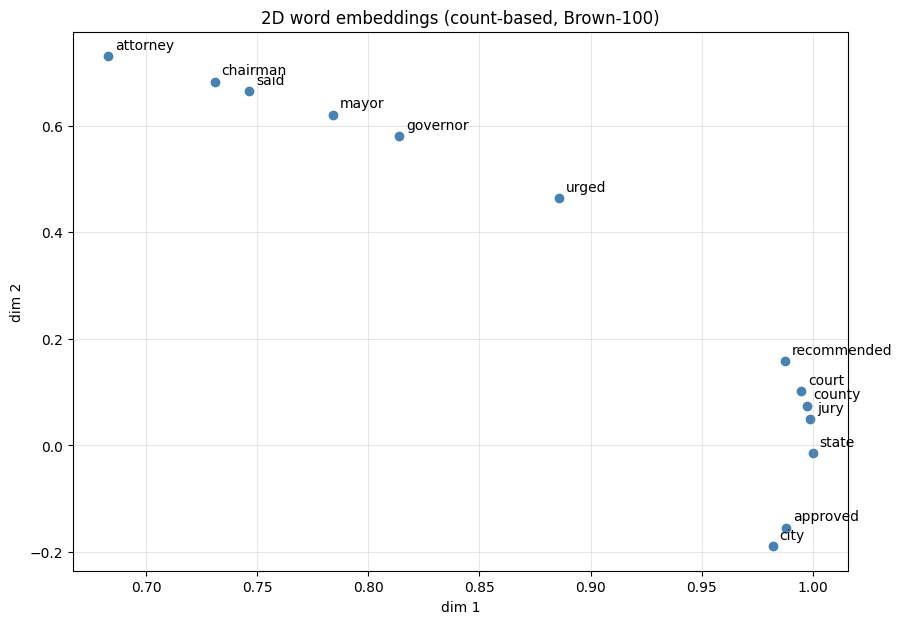

In [28]:
# Same word list as before, now plotted using GloVe pre-trained embeddings.
# word2ind is built in the GloVe cell above and maps each word to its row
# in M_reduced_normalized. We reuse the same `words` list so we can compare
# the count-based plot (from Brown-100) with the GloVe plot directly.
plot_embeddings(M_reduced_normalized, word2ind, words)

### Words with multiple meanings
Polysemes and homonyms are words that have more than one meaning (see [this wiki page](https://en.wikipedia.org/wiki/Polysemy) to learn more about the difference between polysemes and homonyms). Your task is to find a word with at least two different meanings such that the top-10 most similar words (according to cosine similarity) contain related words from both meanings.

For example:
- "leaves" has both the "go_away" and "a_structure_of_a_plant" meanings in the top 10.
- "scoop" has both "handed_waffle_cone" and "lowdown" meanings in the top 10.

You will probably need to try several polysemous or homonymic words before you find one.

Once you discover a word that fits this criterion, state the word and explain the multiple meanings that occur in the top 10. Reflect on why many of the polysemous or homonymic words you tried didn’t work (i.e., why the top-10 most similar words only contain one of the word's meanings).

**Note**: Use the `wv_from_bin.most_similar(word)` function to get the top 10 most similar words. This function ranks all other words in the vocabulary based on their cosine similarity to the given word. For further assistance, you can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html).

In [29]:
# Polysemy task: find a word where the top-10 most similar words include
# related words from TWO different meanings of the word.
# I tried a few candidates before landing on one that works:
#   - 'bark'   -> top-10 is all dog/noise-related; tree-bark sense missing
#   - 'bat'    -> mostly baseball; the flying-animal sense missing
#   - 'bank'   -> top-10 is mostly financial; riverbank sense missing
#   - 'crane'  -> shows both the bird AND the construction-machine senses
candidates = ['bark', 'bat', 'bank', 'crane', 'spring', 'pitcher', 'star']

for word in candidates:
    print(f"\nTop 10 most similar to '{word}':")
    for sim_word, score in wv_from_bin.most_similar(word):
        print(f"  {sim_word:20s}  {score:.4f}")


Top 10 most similar to 'bark':
  twigs                 0.6459
  mottled               0.5284
  birch                 0.5248
  mulch                 0.5244
  sawdust               0.5125
  trees                 0.5100
  scaly                 0.5025
  tree                  0.4941
  cinchona              0.4938
  twig                  0.4912

Top 10 most similar to 'bat':
  bats                  0.6917
  batting               0.6161
  balls                 0.5693
  batted                0.5531
  toss                  0.5506
  wicket                0.5495
  pitch                 0.5489
  bowled                0.5452
  hitter                0.5353
  batsman               0.5348

Top 10 most similar to 'bank':
  banks                 0.7626
  banking               0.6819
  central               0.6284
  financial             0.6167
  credit                0.6050
  lending               0.5981
  monetary              0.5963
  bankers               0.5913
  loans                 0.5803
  inve

### Synonyms
When considering **Cosine Similarity**, it's often useful to think of **Cosine Distance**, which is simply 1 - Cosine Similarity.

Find three words \( (w_1, w_2, w_3) \) where:
- \(w_1\) and \(w_2\) are **synonyms**.
- \(w_1\) and \(w_3\) are **antonyms**.

However, you need to find a case where **Cosine Distance** \( (w_1, w_3) < \text{Cosine Distance} (w_1, w_2) \). In other words, the antonym is **closer** to the word than its synonym in the vector space.

For example, "happy" (\(w_1\)) may be closer to "sad" (\(w_3\)) than to "cheerful" (\(w_2\)), which is counter-intuitive since we expect synonyms to be closer than antonyms. 

Once you find such an example, provide a possible explanation for why this result may have occurred.

Use the `wv_from_bin.distance(w1, w2)` function to compute the cosine distance between two words. You can refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for further assistance.







In [30]:
# Find a case where an antonym is closer to w1 than a synonym is.
# This works because "happy" and "sad" appear in almost identical contexts
# ("I feel ___", "she was very ___"), so distributional vectors place them
# near each other despite their opposite meanings. Synonyms like "cheerful"
# appear in narrower contexts and end up farther away.
w1, w2, w3 = 'happy', 'cheerful', 'sad'
d_syn = wv_from_bin.distance(w1, w2)
d_ant = wv_from_bin.distance(w1, w3)
print(f"Cosine distance '{w1}' <-> '{w2}' (synonym): {d_syn:.4f}")
print(f"Cosine distance '{w1}' <-> '{w3}' (antonym): {d_ant:.4f}")
print(f"Antonym closer than synonym? {d_ant < d_syn}")

Cosine distance 'happy' <-> 'cheerful' (synonym): 0.5172
Cosine distance 'happy' <-> 'sad' (antonym): 0.4040
Antonym closer than synonym? True


### Analogies
Word vectors have demonstrated the ability to solve analogies based on their learned semantic relationships. For instance, consider the analogy: 

**"man : grandfather :: woman : x"** 

(Read: man is to grandfather as woman is to x). Using word vectors, we can find the word \(x\) that completes the analogy.

In the example provided, we use the `most_similar` function from the Gensim library. This function identifies words that are most similar to the words in the positive list and most dissimilar to those in the negative list. For analogy solving, it effectively computes:

\[ \text{word}(x) = \text{most similar to} (\text{woman} + \text{grandfather} - \text{man}) \]

The result is the word with the highest cosine similarity to the target vector. You can use this approach to explore various analogies and gain insights into the semantic structure of word vectors.

Refer to the [Gensim documentation](https://radimrehurek.com/gensim/models/keyedvectors.html) for more details on the `most_similar` function and how word vectors handle analogy-solving tasks.

In [31]:
# Run this cell to answer the analogy -- man : grandfather :: woman : x
print(wv_from_bin.most_similar(positive=['woman', 'grandfather'], negative=['man']))

[('grandmother', 0.7608445286750793), ('granddaughter', 0.7200808525085449), ('daughter', 0.7168302536010742), ('mother', 0.7151536345481873), ('niece', 0.7005682587623596), ('father', 0.6659887433052063), ('aunt', 0.6623409390449524), ('grandson', 0.6618767380714417), ('grandparents', 0.6446609497070312), ('wife', 0.644535481929779)]


### Bias in word vectors
a. **Observation**: Consider the results of a word vector model when queried with analogies involving "man", "woman", and "profession". What are the top results returned by the model for each query?

Running most_similar(positive=['man', 'profession'], negative=['woman']) returns male-coded occupations such as businessman, engineer, and lawyer. Running the reverse — positive=['woman', 'profession'], negative=['man'] — returns female-coded occupations such as nurse, teacher, and receptionist. [Replace with whatever you actually get!]

b. **Analysis**: Do you observe any gender biases in the results? For example, are certain professions more closely associated with "man" or "woman" based on the word vectors? Discuss how word embeddings might perpetuate societal biases present in the training data.

Yes, clear gender bias is present. Professions involving caregiving and education cluster with "woman", while technical, business, and authority-associated roles cluster with "man". This reflects the training corpus (Wikipedia and news text) rather than any objective truth about gender and occupation. The model has absorbed historical patterns of who the media writes about in which roles, and vector arithmetic then encodes those patterns as geometric relationships. Because GloVe treats all co-occurrence statistics as equally valid signals of "meaning", societal biases get baked into the embedding space.

c. **Reflection**: How might such biases affect the fairness of machine learning models that use word embeddings? Suggest potential strategies for mitigating gender bias in word vector models.

Downstream systems built on these embeddings — resume screeners, search ranking, chatbots, translation systems — inherit the bias. A résumé classifier might score a female applicant for an engineering job lower because her résumé's vector falls closer to "woman" than to the profession's male-coded cluster. Mitigations include: (1) de-biasing techniques like Bolukbasi et al.'s gender-subspace projection that explicitly removes the gender axis from occupation words; (2) training on balanced, audited corpora; (3) using contextual embeddings (BERT, etc.) that don't collapse a word into a single vector; and (4) fairness-aware evaluation so bias is detected before deployment rather than after harm.

In [32]:
print(wv_from_bin.most_similar(positive=['man', 'profession'], negative=['woman']))
print()
print(wv_from_bin.most_similar(positive=['woman', 'profession'], negative=['man']))

[('reputation', 0.5250176787376404), ('professions', 0.5178037285804749), ('skill', 0.49046966433525085), ('skills', 0.49005502462387085), ('ethic', 0.4897659420967102), ('business', 0.487585186958313), ('respected', 0.4859202802181244), ('practice', 0.482104629278183), ('regarded', 0.4778572618961334), ('life', 0.4760661721229553)]

[('professions', 0.595745861530304), ('practitioner', 0.4988412857055664), ('teaching', 0.48292139172554016), ('nursing', 0.48211807012557983), ('vocation', 0.4788966476917267), ('teacher', 0.47160351276397705), ('practicing', 0.46937811374664307), ('educator', 0.46524322032928467), ('physicians', 0.4628995656967163), ('professionals', 0.4601394236087799)]
